## 06 규제 선형 모델 - 릿지,라쏘,엘라스틱넷

### 릿지 회귀

In [14]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

ridge =Ridge(alpha=10)
neg_mse_scores=cross_val_score(ridge,X_data,y_target,scoring="neg_mean_squared_error",cv=5)
rmse_scores=np.sqrt(-1*neg_mse_scores)
avg_rmse=np.mean(rmse_scores)

NameError: name 'X_data' is not defined

In [15]:
print('5 folds의 개별 negative mse scores:',np.round(neg_mse_scores,3))
print('5 folds의 개별 RMSE scores:',np.round(rmse_scores,3))
print('5 folds의 평균 RMSE:{0:.3f}'.format(avg_rmse))

NameError: name 'neg_mse_scores' is not defined

In [17]:
alphas=[0,0.1,1,10,100]
for alpha in alphas:
    ridge=Ridge(alpha=alpha)

    neg_mse_scores=cross_val_score(ridge,X_data,y_target,scoring="neg_mean_squared_error",cv=5)
    avg_rmse=np.mean(np.sqrt(-1*neg_mse_scores))
    print('alpha{0}일때 5folds의 평균 RMSE:{1:.3f}'.format(alpha,avg_rmse))

NameError: name 'X_data' is not defined

NameError: name 'pd' is not defined

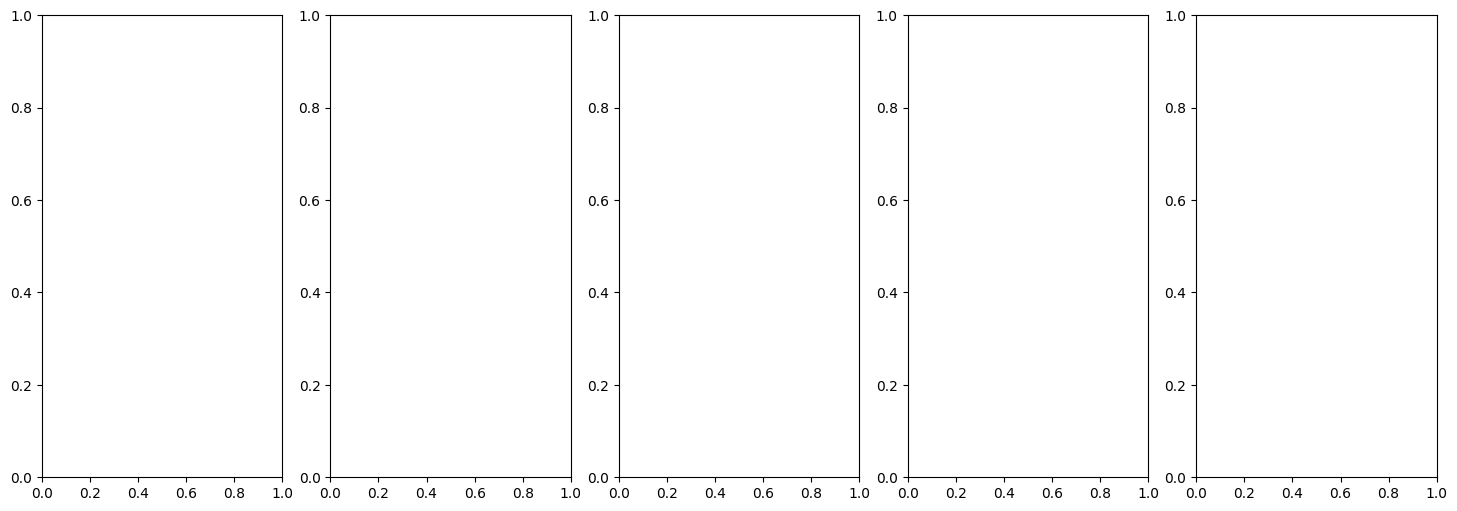

In [19]:
fig,axs=plt.subplots(figsize=(18,6),nrows=1,ncols=5)
coeff_df=pd.DataFrame()

for pos,alpha in enumerate(alphas):
    ridge=Ridge(alpha=alpha)
    ridge.fit(X_data,y_target)
    coeff=pd.Series(data=ridge.coef_,index=X_data.columns )
    colname='alpha:'+str(alpha)
    coeff_df[colname]=coeff
    coeff=coeff.sort_values(ascending=False)
    axs[pos].set_title(colname)
    axs[pos].set_xlim(-3,6)
    sns.barplot(x=coeff.values,y=coeff.index,ax=axs[pos])

plt.show()

In [20]:
ridge_alphas=[0,0.1,1,10,100]
sort_columns='alpha:'+str(ridge_alphas[0])
coeff_df.sort_values(by=sort_column,ascending=False)

NameError: name 'coeff_df' is not defined

### 라쏘회귀

w절댓값에 패널티 부여하는 L1규제를 선형회귀에 적용한 것이 라쏘회귀

In [23]:
from sklearn.linear_model import Lasso,ElasticNet

def get_linear_reg_eval(model_name,params=None,X_data_n=None,y_target_n=None,
                        verbose=True,return_coeff=True):
    coeff_df=pd.DataFrame()
    if verbose:print('#######',model_name,'#######')
    for param in params:
        if model_name=='Ridge':model=Ridge(alpha=param)
        elif model_name=='Lasso':model=Lasso(alpha=param)
        elif model_name=='ElasticNet':model=ElasticNet(alpha=param,l1_ratio=0.7)
        neg_mse_scores=cross_val_score(model,X_data_n,y_target_n,scoring="neg_mean_squared_error",cv=5)
        avg_rmse=np.mean(np,sqrt(-1*neg_mse_scores))
        print('alpha {0}일때 5폴드 세트의 평균 RMSE:{1:.3f}'.format(param,avg_rmse))

        model.fit(X_data_n,y_target_n)
        if return_coeff:
            coeff=pd.Series(data=model.coef_,index=X_data_n.columns)
            colname='alpha:'+str(param)
            coeff_df[colname]=coeff

    return coeff_df


In [24]:
lasso_alphas=[0.07,0.1,0.5,1,3]
coeff_lasso_df=get_linear_reg_eval('Lasso',params=lasso_alphas,X_data_n=X_data,y_target_n=y_target)

NameError: name 'X_data' is not defined

In [25]:
sort_column='alpha:'+str(lasso_alphas[0])
coeff_lasso_df.sort_values(by=sort_column,ascending=False)

NameError: name 'coeff_lasso_df' is not defined

### 엘라스틱넷 회귀

L2규제와 L1규제를 결합한 회귀

In [26]:
elastic_alphas=[0.07,0.1,0.5,1,3]
coeff_elastic_df=get_linear_reg_eval('ElasticNet',params=elastic_alphas,X_data_n=X_data,y_target_n=y_target)

NameError: name 'X_data' is not defined

In [27]:
sort_column='alpha:'+str(elastic_alphas[0])
coeff_elastic_df.sort_values(by=sort_column,ascending=False)

NameError: name 'coeff_elastic_df' is not defined

### 선형회귀모델을 위한 데이터 변환

In [28]:
from  sklearn.preprocessing import StandardScaler,MinMax,Scaler,PolynomialFeatures

def get_scaled_data(method='None',p_degree=None,input_data=None):
    if method=='Standard':
        scaled_data=StandardScaler().fit_transform(input_data)
    elif method=='MinMax':
        scaled_data=MinMaxScaler().fit_transform(input_data)

    elif method=='Log':
        scaled_data=np.log1p(input_data)

    else:
        scaled_data=input_data

    if p_degree != None:
        scaled_data = PolynomialFeatures(degree=p_degree,include_bias=False).fit_transform(scaled_data)

    return scaled_data

ImportError: cannot import name 'MinMax' from 'sklearn.preprocessing' (C:\Users\Yeeun\anaconda3\Lib\site-packages\sklearn\preprocessing\__init__.py)

In [29]:
alphas=[0.1,1,10,100]
scale_methods=[(None,None),('Standard',None),('Standard',2),
               ('MinMax',None,('MinMax',2),('Log',None)]
for scale_method in scale_methods:
    X_data_scaled=get_scaled_data(method=scale_method[0],p_degree=scale_method[1],
                                  input_data=X_data)
    print('\n## 변환유형:{0},Polynomial Degree:{1}'.format(scale_method[0],scale_method[1]))
    get_linear_reg_eval('Ridge',params=alphas,X_data_n=X_data_scaled,y_target_n=y_target,verbose=False,return_coeff=False)

SyntaxError: closing parenthesis ']' does not match opening parenthesis '(' (951438353.py, line 3)

### 로지스틱회귀

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

cancer=load_breast_cancer()

In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
scaler=StandardScaler()
data_scaled=scaler.fit_transform(cancer.data)
X_train,X_test,y_train,y_test=train_test_split(data_scaled,cancer.target,test_size=0.3,random_state=0)

In [34]:
from sklearn.metrics import accuracy_score,roc_auc_score

lr_clf=LogisticRegression()
lr_preds=lr_clf.predict(X_test)
lr_preds_proba=lr_clf.predict_proba(X_test)[:,1]

print('accuracy:{0:.3f},roc_auc:{1:.3f}'.format(accuaracy_score(y_test,lr_preds),
                                                roc_auc_score(y_test,lr_preds_proba)))

NotFittedError: This LogisticRegression instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [35]:
solvers=['lbfgs','liblinear','newton-cg','sag','saga']
for solver in solvers:
    lr_clf=LogisticRegression(solver=solver,max_iter=600)
    lr_clf.fit(X_train,y_train)
    lr_preds=lr_clf.predict(X_test)
    lr_preds_proba=lr_clf.predict_proba(X_test)[:,1]

    print('solver:{0},accuracy:{1:.3f},roc_auc:{2:.3f}'.format(solver,accuracy_score(y_test,lr_preds),roc_auc_score(y_test,lr_preds_proba)))

solver:lbfgs,accuracy:0.977,roc_auc:0.995
solver:liblinear,accuracy:0.982,roc_auc:0.995
solver:newton-cg,accuracy:0.977,roc_auc:0.995
solver:sag,accuracy:0.982,roc_auc:0.995
solver:saga,accuracy:0.982,roc_auc:0.995


In [ ]:
from sklearn.model_selection import GridSearchCV
params={'solver':['liblinear','lbfgs'],'C':[0.01,0.1,1,5,10],'penalty':['12','11']}
lr_clf=LogisticRegression()
grid_clf=GridSearchCV(lr_clf,param_grid=params,scoring='accuracy',cv=3)
grid_clf.fit(data_scaled,cancer.target)
print('최적 하이퍼 파라미터:{0},최적평균 정확도:{1:.3f}'.format(grid_clf.best_params_,grid_clf.best_score_))